In [1]:
import tensorflow as tf
print(tf.version.VERSION)
print("Dispositivos disponibles:", tf.config.list_physical_devices('GPU'))

2.19.0
Dispositivos disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
#Cargamos el dataset

cifar10 = tf.keras.datasets.cifar10
(train_img, train_labels), (test_img, test_labels) = cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [3]:
train_img.shape

(50000, 32, 32, 3)

In [4]:
from sklearn.model_selection import train_test_split

#Dividimos dataset train en 80% train y 20% validación
train_img, validation_img, train_labels, validation_labels = train_test_split(train_img,
                                                                              train_labels,
                                                                              test_size=0.2,
                                                                              random_state=1234)
print(f"Imágenes de entrenamiento : {train_img.shape}")
print(f"Imágenes de validación : {validation_img.shape}")
print(f"Imágenes de test : {test_img.shape}")

Imágenes de entrenamiento : (40000, 32, 32, 3)
Imágenes de validación : (10000, 32, 32, 3)
Imágenes de test : (10000, 32, 32, 3)


In [5]:
#Normalizamos datos
train_img  = train_img / 255.0
validation_img  = validation_img / 255.0
test_img = test_img / 255.0


/tmp/ipython-input-2698644633.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Class: {labels[int(train_labels[i])]}")


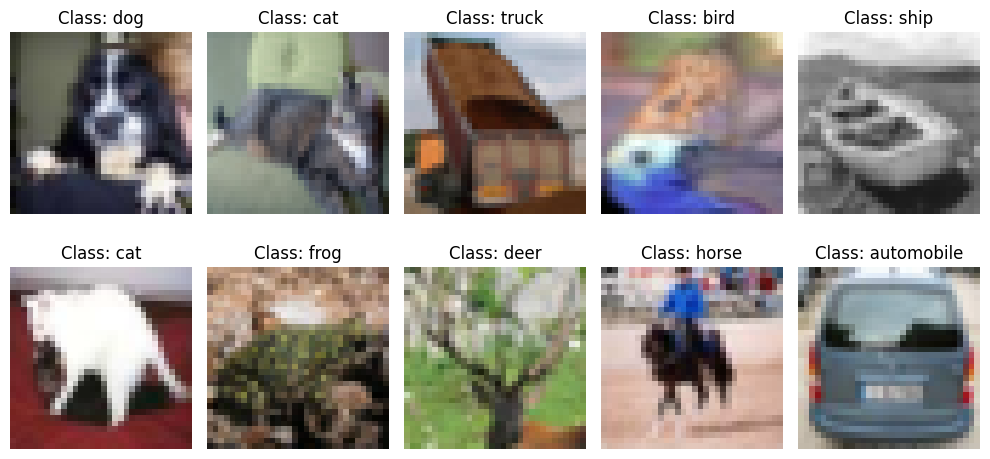

In [6]:
import matplotlib.pyplot as plt

labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize = (10,12))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.subplots_adjust(hspace=0.3,wspace=0.3)
    plt.imshow(train_img[i])
    plt.title(f"Class: {labels[int(train_labels[i])]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
#Reseteamos tensorflow (liberar memoria)
tf.keras.backend.clear_session()

In [8]:
# Definimos el modelo
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
  Input(shape=(32, 32, 3)), # Define los datos de entrada
  Conv2D(filters=32, kernel_size=(3,3), # Primera capa de convolución (kernel 3x3)
         strides=(1,1), padding='same', activation='relu'),
  Flatten(),
  Dense(128, activation='relu'),
  Dense(10, activation='softmax') # 10 neuronas de salida softmax (números 0..9)
])

In [9]:
# Compilación del modelo
model.compile(optimizer = tf.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,196,618 (16.01 MB)

 Trainable params: 4,196,618 (16.01 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Monitoreamos pérdida en validación. Parar en 6 iteraciones sin mejorar. Restauramos mejores pesos
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(
  monitor='val_loss',   # Monitorea la pérdida en validación
  factor=0.5, # Reduce la tasa de aprendizaje a la mitad
  patience=2, # Espera 2 iteraciones sin mejora antes de reducir
  min_lr=1e-6 # No permite que la tasa de aprendizaje baje de 1e-6
)

history = model.fit(train_img,
  train_labels,
  epochs = 30,
  validation_data=(validation_img, validation_labels),
  callbacks=[early_stop, reduce_lr]  # Agregar ambas estrategias
)

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.3934 - loss: 1.6979 - val_accuracy: 0.5384 - val_loss: 1.2829 - learning_rate: 0.0010
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5768 - loss: 1.2024 - val_accuracy: 0.5629 - val_loss: 1.2256 - learning_rate: 0.0010
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6413 - loss: 1.0151 - val_accuracy: 0.5750 - val_loss: 1.2067 - learning_rate: 0.0010
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6927 - loss: 0.8705 - val_accuracy: 0.5936 - val_loss: 1.2094 - learning_rate: 0.0010
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7477 - loss: 0.7257 - val_accuracy: 0.5726 - val_loss: 1.2825 - learning_rate: 0.0010
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8199 - loss: 0.5385 - val_accuracy: 0.5983 - val_loss: 1.2893 - learning_rate: 5.0000e-04
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.85

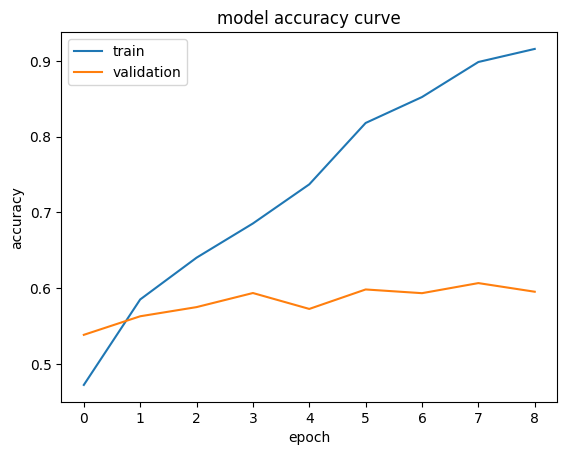

In [11]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy curve')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

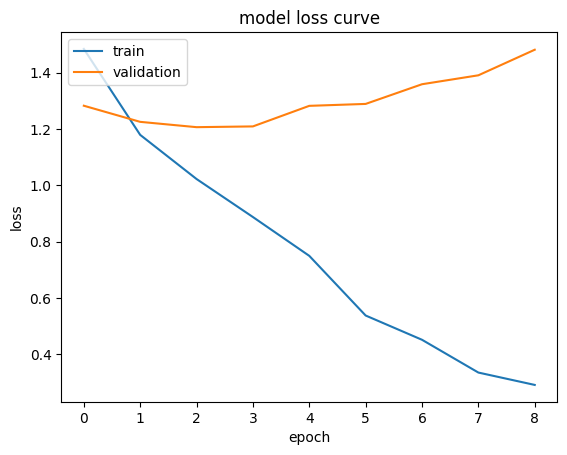

In [12]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss curve')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()


In [13]:
model.evaluate(test_img, test_labels)
# [perdida, precision]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5829 - loss: 1.1872


[1.2027758359909058, 0.5777999758720398]